In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataframelocate.csv')

#df.head()
df.info()
#df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7698 entries, 0 to 7697
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          7698 non-null   object 
 1   screen_name                   7698 non-null   object 
 2   followers_count               7695 non-null   float64
 3   friends_count                 7695 non-null   float64
 4   post_count                    7695 non-null   float64
 5   lang                          7695 non-null   object 
 6   location                      5752 non-null   object 
 7   default_profile_image         7695 non-null   object 
 8   profile_use_background_image  7695 non-null   object 
 9   verified                      7695 non-null   object 
 10  description                   7085 non-null   object 
 11  created_at                    7689 non-null   object 
 12  label                         7698 non-null   int64  
 13  has

In [ ]:
#variable location tiene muchos NaN
df['location'].isna().sum()


In [ ]:
df.isna().sum()
#verified es una variable que no deberia tener nulos ya que deberia especificar si tiene o no verificados = reemplazar por no verificado o eliminar outlier
#created_at no tiene sentido que no haya fecha de creación = eliminar outliers
#followers/friends/post_count = cambiar nan por 0
#description = reemplazar los NaN por un texto donde se refiera a que el usuario no entrego una descripción de perfil
#Transformar los datos de location a valores sin mayusculas, comas, y puntos, con tal de que el codigo entienda que son el mismo dato


In [ ]:
df.created_at

,created_at
0,11-06-2013 11:20
1,13-05-2014 10:37
2,04-05-2011 23:30
3,17-09-2010 14:02
4,06-02-2015 04:10
...,...
7693,14-04-2014 15:06
7694,02-05-2015 13:09
7695,10-05-2014 01:54
7696,12-06-2015 15:33


In [ ]:
display(df['location'].sample(10))

In [ ]:
location_counts = df['location'].value_counts()
locations_appearing_once = location_counts[location_counts == 2]

locations_to_remove = locations_appearing_once.index
df['location'] = df['location'].replace(locations_to_remove, np.nan)

print("Valores nulos después de eliminar locaciones de una sola aparición:")
print(df['location'].isna().sum())

In [ ]:
location_counts = df['location'].value_counts()
locations_appearing_once = location_counts[location_counts == 1]

print(f"El número de locaciones que aparecen solo una vez es: {len(locations_appearing_once)}")


In [ ]:
# Filter for locations containing 'new york' (case-insensitive) and display their value counts
ny_variations = df[df['location'].str.contains('samoa', na=False)]
display(ny_variations['location'].value_counts())

In [ ]:
# Get the unique variations of 'new york' from the previously identified ny_variations DataFrame
unique_ny_variations = ny_variations['location'].unique()

# Replace each of these unique variations with 'new york' in the original DataFrame
for variation in unique_ny_variations:
    df['location'] = df['location'].str.replace(variation, 'samoa', regex=False)

# Display the top locations again to confirm the consolidation
display(df['location'].value_counts().head(10))

In [ ]:
df['has_location'] = df['location'].apply(lambda x: 0 if pd.isna(x) or str(x).strip() == "" else 1)
display(df['has_location'].value_counts())

In [ ]:
import re

def clean_location(text):
    if pd.isna(text):
        return text
    text = text.lower()
    text = re.sub(r'[^a-zA-Záéíóúñ\s,]', '', text)  # elimina símbolos raros
    text = text.strip()
    return text

df['location_clean'] = df['location'].apply(clean_location)

In [ ]:
!pip install geopy

In [ ]:
len(df['location_clean'].dropna().unique())

In [ ]:
from geopy.geocoders import Nominatim
import time # Import the time module
geolocator = Nominatim(user_agent="geo_checker")

def is_real_location(location_name):
    try:
        # Some locations might be too general or too short to be meaningful
        if not isinstance(location_name, str) or len(location_name.strip()) < 3:
            return False

        location = geolocator.geocode(location_name, timeout=20)  # Set a timeout for geocoding requests
        return location is not None
    except Exception as e:
        # Handle potential errors during geocoding, e.g., network issues
        print(f"Error geocoding '{location_name}': {e}")
        return False

# Aplicar solo a valores únicos (optimización clave)
unique_locations = df['location_clean'].dropna().unique()

location_dict = {}

for loc in unique_locations:
    location_dict[loc] = is_real_location(loc)
    time.sleep(10)

df['is_real_location'] = df['location_clean'].map(location_dict)

In [ ]:
display(df[['location', 'location_clean', 'is_real_location']])

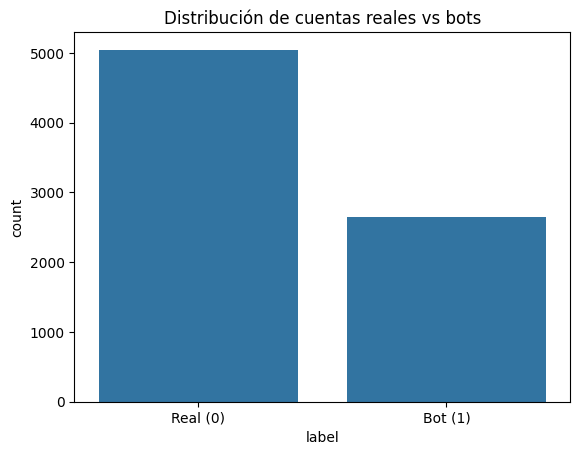

In [ ]:
#Grafico Distribución de bots vs reales
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='label')
plt.title('Distribución de cuentas reales vs bots')
plt.xticks([0,1], ['Real (0)', 'Bot (1)'])
plt.show()

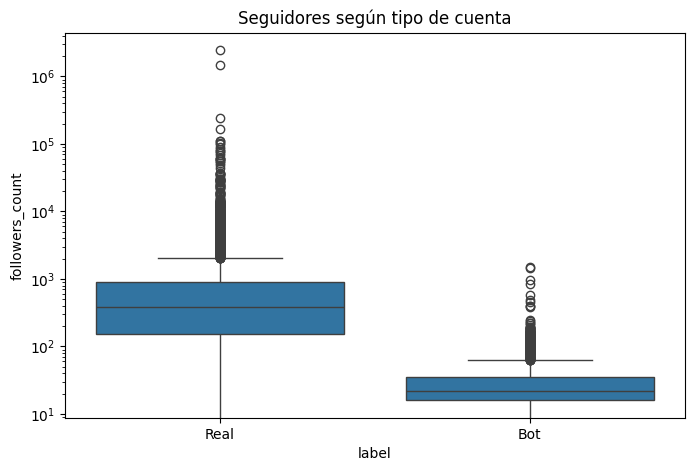

In [ ]:
#Grafico Seguidores según tipo de cuenta
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='followers_count')
plt.title('Seguidores según tipo de cuenta')
plt.xticks([0,1], ['Real', 'Bot'])
plt.yscale('log')   # importante por valores extremos
plt.show()

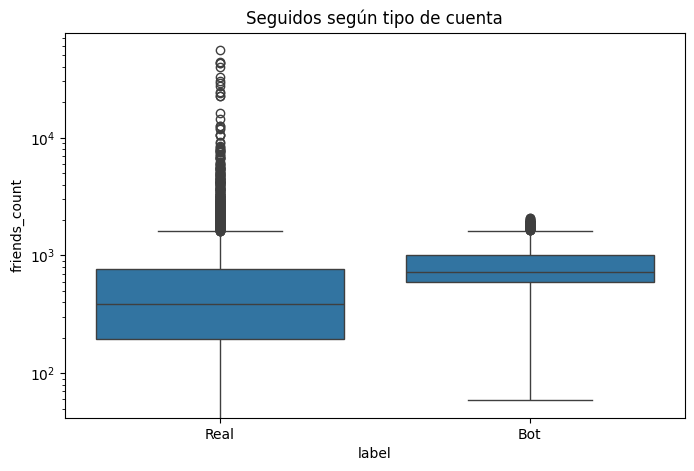

In [ ]:
#Grafico Seguidos (friends_count) por tipo
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='friends_count')
plt.title('Seguidos según tipo de cuenta')
plt.xticks([0,1], ['Real', 'Bot'])
plt.yscale('log')
plt.show()

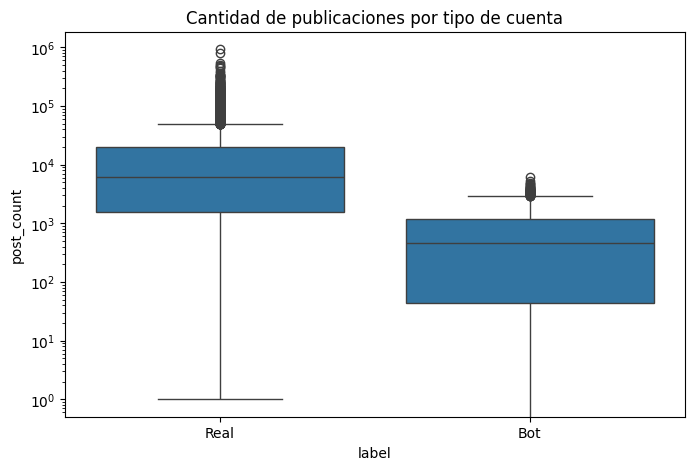

In [ ]:
#Grafico Cantidad de publicaciones
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='post_count')
plt.title('Cantidad de publicaciones por tipo de cuenta')
plt.xticks([0,1], ['Real', 'Bot'])
plt.yscale('log')
plt.show()

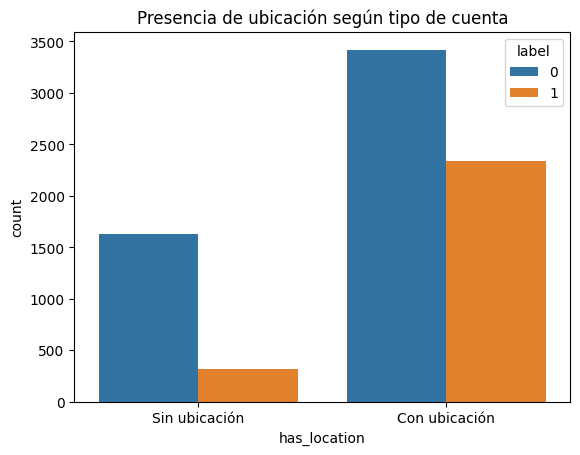

In [ ]:
#Grafico ¿Tener ubicación ayuda a detectar bots?
sns.countplot(data=df, x='has_location', hue='label')
plt.title('Presencia de ubicación según tipo de cuenta')
plt.xticks([0,1], ['Sin ubicación', 'Con ubicación'])
plt.show()

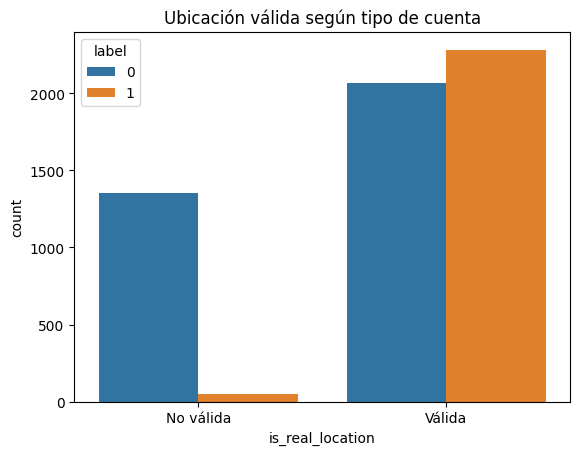

In [ ]:
#Grafico Ubicación real vs falsa
sns.countplot(data=df, x='is_real_location', hue='label')
plt.title('Ubicación válida según tipo de cuenta')
plt.xticks([0,1], ['No válida', 'Válida'])
plt.show()

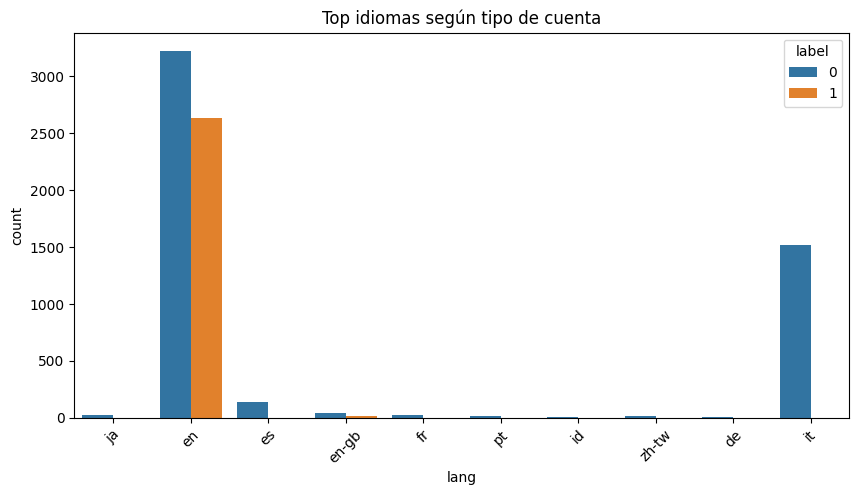

In [ ]:
#Grafico Idioma más frecuente
top_lang = df['lang'].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.countplot(data=df[df['lang'].isin(top_lang)], x='lang', hue='label')
plt.title('Top idiomas según tipo de cuenta')
plt.xticks(rotation=45)
plt.show()

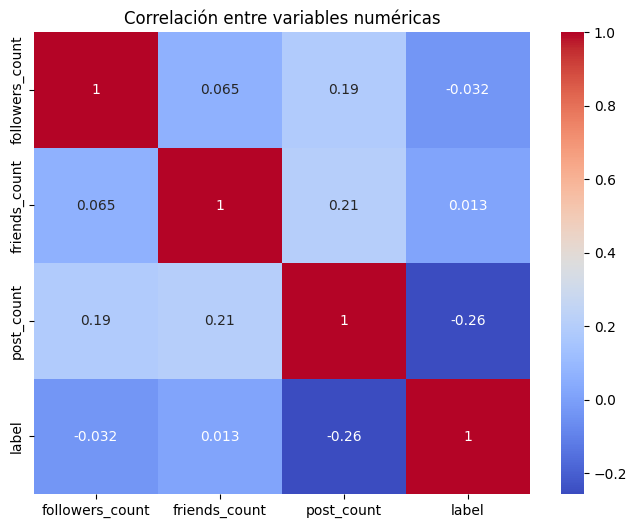

In [ ]:
#Grafico Correlación numérica
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()